In [1]:
import pandas as pd

In [4]:
old_data = pd.read_csv("/workspace/scratch_space_arjun/PlantCLEF2026/src_experiments/002_bioclip_tile_zero_shot_v2/data/PlantCLEF2024_single_plant_training_metadata.csv", sep=";")
old_data.head()

/tmp/ipykernel_3621/863590509.py:1: DtypeWarning: Columns (0: partner) have mixed types. Specify dtype option on import or set low_memory=False.
  old_data = pd.read_csv("/workspace/scratch_space_arjun/PlantCLEF2026/src_experiments/002_bioclip_tile_zero_shot_v2/data/PlantCLEF2024_single_plant_training_metadata.csv", sep=";")


,image_name,organ,species_id,obs_id,license,partner,author,altitude,latitude,longitude,gbif_species_id,species,genus,family,dataset,publisher,references,url,learn_tag,image_backup_url
0,59feabe1c98f06e7f819f73c8246bd8f1a89556b.jpg,leaf,1396710,1008726402,cc-by-sa,NaN,Gulyás Bálint,205.9261,47.592160,19.362895,5284517.0,Taxus baccata L.,Taxus,Taxaceae,plantnet,plantnet,https://identify.plantnet.org/fr/k-southwester...,https://bs.plantnet.org/image/o/59feabe1c98f06...,train,https://lab.plantnet.org/LifeCLEF/PlantCLEF202...
1,dc273995a89827437d447f29a52ccac86f65476e.jpg,leaf,1396710,1008724195,cc-by-sa,NaN,vadim sigaud,323.7520,47.906703,7.201746,5284517.0,Taxus baccata L.,Taxus,Taxaceae,plantnet,plantnet,https://identify.plantnet.org/fr/k-southwester...,https://bs.plantnet.org/image/o/dc273995a89827...,train,https://lab.plantnet.org/LifeCLEF/PlantCLEF202...
2,416235e7023a4bd1513edf036b6097efc693a304.jpg,leaf,1396710,1008721908,cc-by-sa,NaN,fil escande,101.3160,48.826774,2.352774,5284517.0,Taxus baccata L.,Taxus,Taxaceae,plantnet,plantnet,https://identify.plantnet.org/fr/k-southwester...,https://bs.plantnet.org/image/o/416235e7023a4b...,train,https://lab.plantnet.org/LifeCLEF/PlantCLEF202...
3,cbd18fade82c46a5c725f1f3d982174895158afc.jpg,leaf,1396710,1008699177,cc-by-sa,NaN,Desiree Verver,5.1070,52.190427,6.009677,5284517.0,Taxus baccata L.,Taxus,Taxaceae,plantnet,plantnet,https://identify.plantnet.org/fr/k-southwester...,https://bs.plantnet.org/image/o/cbd18fade82c46...,train,https://lab.plantnet.org/LifeCLEF/PlantCLEF202...
4,f82c8c6d570287ebed8407cefcfcb2a51eaaf56e.jpg,leaf,1396710,1008683100,cc-by-sa,NaN,branebrane,165.3390,45.794739,15.965862,5284517.0,Taxus baccata L.,Taxus,Taxaceae,plantnet,plantnet,https://identify.plantnet.org/fr/k-southwester...,https://bs.plantnet.org/image/o/f82c8c6d570287...,train,https://lab.plantnet.org/LifeCLEF/PlantCLEF202...


In [6]:
new_data = pd.read_csv("/workspace/plantclef/processed/inat_research_grade_manifest.csv")
new_data.head()

,image_path,species_id,gbif_species_id,gbif_occurrence_id,license,scientific_name,url
0,/workspace/plantclef/raw/inat_research_grade/1...,1396710,5284517,5938299218,http://creativecommons.org/licenses/by-nc/4.0/...,Taxus baccata L.,https://inaturalist-open-data.s3.amazonaws.com...
1,/workspace/plantclef/raw/inat_research_grade/1...,1396710,5284517,5938200063,http://creativecommons.org/licenses/by-nc/4.0/...,Taxus baccata L.,https://inaturalist-open-data.s3.amazonaws.com...
2,/workspace/plantclef/raw/inat_research_grade/1...,1396710,5284517,5938168811,http://creativecommons.org/publicdomain/zero/1...,Taxus baccata L.,https://inaturalist-open-data.s3.amazonaws.com...
3,/workspace/plantclef/raw/inat_research_grade/1...,1396710,5284517,5938071098,http://creativecommons.org/licenses/by/4.0/leg...,Taxus baccata L.,https://inaturalist-open-data.s3.amazonaws.com...
4,/workspace/plantclef/raw/inat_research_grade/1...,1396710,5284517,5938251864,http://creativecommons.org/licenses/by/4.0/leg...,Taxus baccata L.,https://inaturalist-open-data.s3.amazonaws.com...


In [7]:
import pandas as pd
import numpy as np

old = old_data.copy()
new = new_data.copy()

# ----------------------------
# Standardize columns
# ----------------------------

old = old.rename(columns={
    "species": "scientific_name_old",
    "url": "url_old",
    "license": "license_old",
    "gbif_species_id": "gbif_species_id_old",
})

new = new.rename(columns={
    "scientific_name": "scientific_name_new",
    "url": "url_new",
    "license": "license_new",
    "gbif_species_id": "gbif_species_id_new",
})

# Convert IDs safely
old["species_id"] = pd.to_numeric(old["species_id"], errors="coerce").astype("Int64")
new["species_id"] = pd.to_numeric(new["species_id"], errors="coerce").astype("Int64")

old["gbif_species_id_old"] = pd.to_numeric(old["gbif_species_id_old"], errors="coerce").astype("Int64")
new["gbif_species_id_new"] = pd.to_numeric(new["gbif_species_id_new"], errors="coerce").astype("Int64")

# Normalize names
old["scientific_name_old_norm"] = old["scientific_name_old"].astype(str).str.strip().str.lower()
new["scientific_name_new_norm"] = new["scientific_name_new"].astype(str).str.strip().str.lower()

In [8]:
summary = pd.DataFrame({
    "dataset": ["old", "new"],
    "rows": [len(old), len(new)],
    "unique_species_id": [old["species_id"].nunique(), new["species_id"].nunique()],
    "unique_gbif_species_id": [old["gbif_species_id_old"].nunique(), new["gbif_species_id_new"].nunique()],
    "unique_scientific_names": [
        old["scientific_name_old_norm"].nunique(),
        new["scientific_name_new_norm"].nunique()
    ],
})

summary

,dataset,rows,unique_species_id,unique_gbif_species_id,unique_scientific_names
0,old,1408033,7806,7796,7806
1,new,1338626,5037,5037,7424


In [9]:
old_species = set(old["species_id"].dropna())
new_species = set(new["species_id"].dropna())

species_overlap = pd.DataFrame({
    "metric": [
        "old species",
        "new species",
        "shared species",
        "new-only species",
        "old-only species",
    ],
    "count": [
        len(old_species),
        len(new_species),
        len(old_species & new_species),
        len(new_species - old_species),
        len(old_species - new_species),
    ],
})

species_overlap

,metric,count
0,old species,7806
1,new species,5037
2,shared species,5037
3,new-only species,0
4,old-only species,2769


In [10]:
old_gbif = set(old["gbif_species_id_old"].dropna())
new_gbif = set(new["gbif_species_id_new"].dropna())

gbif_overlap = pd.DataFrame({
    "metric": [
        "old GBIF species",
        "new GBIF species",
        "shared GBIF species",
        "new-only GBIF species",
        "old-only GBIF species",
    ],
    "count": [
        len(old_gbif),
        len(new_gbif),
        len(old_gbif & new_gbif),
        len(new_gbif - old_gbif),
        len(old_gbif - new_gbif),
    ],
})

gbif_overlap

,metric,count
0,old GBIF species,7796
1,new GBIF species,5037
2,shared GBIF species,5037
3,new-only GBIF species,0
4,old-only GBIF species,2759


In [11]:
old_species_stats = (
    old.groupby("species_id")
    .agg(
        old_n_images=("image_name", "count"),
        old_n_obs=("obs_id", "nunique"),
        old_gbif_species_id=("gbif_species_id_old", "first"),
        old_scientific_name=("scientific_name_old", "first"),
        old_genus=("genus", "first"),
        old_family=("family", "first"),
    )
    .reset_index()
)

new_species_stats = (
    new.groupby("species_id")
    .agg(
        new_n_images=("image_path", "count"),
        new_n_occurrences=("gbif_occurrence_id", "nunique"),
        new_gbif_species_id=("gbif_species_id_new", "first"),
        new_scientific_name=("scientific_name_new", "first"),
    )
    .reset_index()
)

species_compare = old_species_stats.merge(
    new_species_stats,
    on="species_id",
    how="outer",
    indicator=True
)

species_compare["status"] = species_compare["_merge"].map({
    "both": "shared",
    "left_only": "old_only",
    "right_only": "new_only",
})

species_compare["image_gain"] = (
    species_compare["new_n_images"].fillna(0) - species_compare["old_n_images"].fillna(0)
)

species_compare["image_gain_ratio"] = (
    species_compare["new_n_images"] / species_compare["old_n_images"]
)

species_compare = species_compare.drop(columns=["_merge"])

species_compare.head()

,species_id,old_n_images,old_n_obs,old_gbif_species_id,old_scientific_name,old_genus,old_family,new_n_images,new_n_occurrences,new_gbif_species_id,new_scientific_name,status,image_gain,image_gain_ratio
0,1355868,323,301,3140346,Lactuca virosa L.,Lactuca,Asteraceae,500.0,500.0,3140346,Lactuca virosa L.,shared,177.0,1.547988
1,1355869,412,402,5403304,Crepis capillaris (L.) Wallr.,Crepis,Asteraceae,500.0,500.0,5403304,Crepis capillaris (L.) Wallr.,shared,88.0,1.213592
2,1355870,439,404,5403470,Crepis foetida L.,Crepis,Asteraceae,NaN,NaN,<NA>,NaN,old_only,-439.0,NaN
3,1355871,290,278,3093911,Hypochaeris glabra L.,Hypochaeris,Asteraceae,500.0,500.0,3093911,Hypochaeris glabra L.,shared,210.0,1.724138
4,1355872,464,455,3093702,Hypochaeris radicata L.,Hypochaeris,Asteraceae,500.0,300.0,3093702,Hypochaeris radicata L.,shared,36.0,1.077586


In [12]:
shared_species = species_compare[species_compare["status"] == "shared"].copy()

shared_species.sort_values("image_gain", ascending=False).head(30)

,species_id,old_n_images,old_n_obs,old_gbif_species_id,old_scientific_name,old_genus,old_family,new_n_images,new_n_occurrences,new_gbif_species_id,new_scientific_name,status,image_gain,image_gain_ratio
7177,1741752,7,4,3928823,Pulsatilla scherfelii (Ullep.) Skalický,Pulsatilla,Ranunculaceae,500.0,361.0,3928823,Pulsatilla scherfelii (Ullep.) Skalický,shared,493.0,71.428571
2580,1363823,17,7,8222621,Periploca angustifolia Labill.,Periploca,Apocynaceae,500.0,500.0,8222621,Periploca angustifolia Labill.,shared,483.0,29.411765
6571,1649483,51,30,2706035,Coleanthus subtilis (Tratt.) Seidel ex Roem. &...,Coleanthus,Poaceae,500.0,259.0,2706035,Coleanthus subtilis (Tratt.) Seidel ex Roem. &...,shared,449.0,9.803922
6339,1564502,59,25,7307657,Thymus capitellatus Hoffmanns. & Link,Thymus,Lamiaceae,450.0,225.0,7307657,Thymus capitellatus Hoffmanns. & Link,shared,391.0,7.627119
5788,1453545,111,84,2859255,Narcissus × incomparabilis Mill.,Narcissus,Amaryllidaceae,500.0,257.0,2859255,Narcissus × incomparabilis Mill.,shared,389.0,4.504505
3244,1391319,119,115,2739661,Colchicum bulbocodium Ker Gawl.,Colchicum,Colchicaceae,500.0,500.0,2739661,Colchicum bulbocodium Ker Gawl.,shared,381.0,4.201681
6256,1556855,124,121,7525044,Iris planifolia (Mill.) T.Durand & Schinz,Iris,Iridaceae,500.0,300.0,7525044,Iris planifolia (Mill.) T.Durand & Schinz,shared,376.0,4.032258
1319,1359825,150,133,7315023,Roemeria hybrida (L.) DC.,Roemeria,Papaveraceae,520.0,480.0,7315023,Roemeria hybrida (L.) DC.,shared,370.0,3.466667
3857,1393305,136,124,5298224,Iris tuberosa L.,Iris,Iridaceae,500.0,500.0,5298224,Iris tuberosa L.,shared,364.0,3.676471
234,1356435,139,126,5275404,Pteris cretica L.,Pteris,Pteridaceae,500.0,500.0,5275404,Pteris cretica L.,shared,361.0,3.597122


In [13]:
new_only_species = species_compare[species_compare["status"] == "new_only"].copy()

new_only_species.sort_values("new_n_images", ascending=False).head(30)

,species_id,old_n_images,old_n_obs,old_gbif_species_id,old_scientific_name,old_genus,old_family,new_n_images,new_n_occurrences,new_gbif_species_id,new_scientific_name,status,image_gain,image_gain_ratio


In [14]:
old_only_species = species_compare[species_compare["status"] == "old_only"].copy()

old_only_species.sort_values("old_n_images", ascending=False).head(30)

,species_id,old_n_images,old_n_obs,old_gbif_species_id,old_scientific_name,old_genus,old_family,new_n_images,new_n_occurrences,new_gbif_species_id,new_scientific_name,status,image_gain,image_gain_ratio
6992,1737559,770,684,8411755,Aria edulis (Willd.) M.Roem.,Aria,Rosaceae,NaN,NaN,<NA>,NaN,old_only,-770.0,NaN
1251,1359676,621,545,5415040,Olea europaea L.,Olea,Oleaceae,NaN,NaN,<NA>,NaN,old_only,-621.0,NaN
290,1356609,613,590,5331916,Betula pendula Roth,Betula,Betulaceae,NaN,NaN,<NA>,NaN,old_only,-613.0,NaN
3161,1390952,611,563,2875818,Carpinus betulus L.,Carpinus,Betulaceae,NaN,NaN,<NA>,NaN,old_only,-611.0,NaN
5571,1412585,594,507,7515045,Lotus tenuis Waldst. & Kit. ex Willd.,Lotus,Fabaceae,NaN,NaN,<NA>,NaN,old_only,-594.0,NaN
5491,1400126,590,553,2927280,Betonica officinalis L.,Betonica,Lamiaceae,NaN,NaN,<NA>,NaN,old_only,-590.0,NaN
2911,1389550,569,535,3189815,Aesculus hippocastanum L.,Aesculus,Sapindaceae,NaN,NaN,<NA>,NaN,old_only,-569.0,NaN
2296,1362963,562,520,3172347,Fraxinus ornus L.,Fraxinus,Oleaceae,NaN,NaN,<NA>,NaN,old_only,-562.0,NaN
7206,1741903,556,481,3025093,Chamaemespilus alpina (Mill.) K.R.Robertson & ...,Chamaemespilus,Rosaceae,NaN,NaN,<NA>,NaN,old_only,-556.0,NaN
5331,1398690,531,486,7268098,Atocion armeria (L.) Raf.,Atocion,Caryophyllaceae,NaN,NaN,<NA>,NaN,old_only,-531.0,NaN


In [15]:
shared = species_compare[species_compare["status"] == "shared"].copy()

shared["gbif_mismatch"] = (
    shared["old_gbif_species_id"].astype("Int64") != shared["new_gbif_species_id"].astype("Int64")
)

shared["name_mismatch"] = (
    shared["old_scientific_name"].astype(str).str.strip().str.lower()
    != shared["new_scientific_name"].astype(str).str.strip().str.lower()
)

mismatches = shared[
    shared["gbif_mismatch"] | shared["name_mismatch"]
].copy()

mismatches[
    [
        "species_id",
        "old_gbif_species_id",
        "new_gbif_species_id",
        "old_scientific_name",
        "new_scientific_name",
        "gbif_mismatch",
        "name_mismatch",
        "old_n_images",
        "new_n_images",
    ]
].head(50)

,species_id,old_gbif_species_id,new_gbif_species_id,old_scientific_name,new_scientific_name,gbif_mismatch,name_mismatch,old_n_images,new_n_images
25,1355928,5394232,5394232,Taraxacum besarabicum (Hornem.) Hand.-Mazz.,Taraxacum bessarabicum (Hornem.) Hand.-Mazz.,False,True,155,430.0
26,1355932,2891608,2891608,Pelargonium graveolens L'Hér.,Pelargonium graveolens (Thunb.) L'Hér.,False,True,364,93.0
52,1355993,3828217,3828217,Erodium chium (L.) Willd.,Erodium chium (Burm.fil.) Willd.,False,True,183,101.0
84,1356072,3189723,3189723,Plantago ovata Forssk.,Plantago ovata var. fastigiata (E.Morris) S.C....,False,True,156,300.0
155,1356294,8243603,8243603,Cyperus longus L.,Cyperus longus var. tenuiflorus (Rottb.) Boeck...,False,True,313,300.0
158,1356297,2731327,2731327,Cladium mariscus (L.) Pohl,Cladium mariscus subsp. jamaicense (Crantz) Kük.,False,True,243,300.0
171,1356320,6370689,6370689,Capparis spinosa L.,Capparis mariana Jacq.,False,True,498,500.0
220,1356404,5275012,5275012,Pteridium aquilinum (L.) Kuhn,Pteridium pinetorum C.N.Page & R.R.Mill,False,True,283,500.0
277,1356581,3036182,3036182,Hedera iberica (McAll.) Ackerf. & J.Wen,Hedera iberica (Mc All.) Ackerf. & J.Wen,False,True,6,8.0
370,1356834,7267109,7267109,Cerastium ramosissimum Boiss.,Cerastium schmalhausenii Pacz.,False,True,97,104.0


In [16]:
print("Old duplicate image_name rows:", old.duplicated("image_name").sum())
print("Old duplicate obs_id rows:", old.duplicated("obs_id").sum())

print("New duplicate image_path rows:", new.duplicated("image_path").sum())
print("New duplicate gbif_occurrence_id rows:", new.duplicated("gbif_occurrence_id").sum())
print("New duplicate url rows:", new.duplicated("url_new").sum())

Old duplicate image_name rows: 0
Old duplicate obs_id rows: 256129
New duplicate image_path rows: 92878
New duplicate gbif_occurrence_id rows: 93541
New duplicate url rows: 93713


In [17]:
new[new.duplicated("gbif_occurrence_id", keep=False)].sort_values("gbif_occurrence_id").head(20)

,image_path,species_id,gbif_species_id_new,gbif_occurrence_id,license_new,scientific_name_new,url_new,scientific_name_new_norm
512063,/workspace/plantclef/raw/inat_research_grade/1...,1497667,2765120,891158644,http://creativecommons.org/licenses/by-nc/4.0/...,Tradescantia sillamontana Matuda,https://inaturalist-open-data.s3.amazonaws.com...,tradescantia sillamontana matuda
230446,/workspace/plantclef/raw/inat_research_grade/1...,1497667,2765120,891158644,http://creativecommons.org/licenses/by-nc/4.0/...,Tradescantia sillamontana Matuda,https://inaturalist-open-data.s3.amazonaws.com...,tradescantia sillamontana matuda
328804,/workspace/plantclef/raw/inat_research_grade/1...,1667197,7790614,891159083,http://creativecommons.org/licenses/by-nc/4.0/...,Crataegus coccinea L.,https://inaturalist-open-data.s3.amazonaws.com...,crataegus coccinea l.
522227,/workspace/plantclef/raw/inat_research_grade/1...,1667197,7790614,891159083,http://creativecommons.org/licenses/by-nc/4.0/...,Crataegus coccinea L.,https://inaturalist-open-data.s3.amazonaws.com...,crataegus coccinea l.
485838,/workspace/plantclef/raw/inat_research_grade/1...,1487336,8406968,899951537,http://creativecommons.org/licenses/by-nc/4.0/...,Mammillaria elongata subsp. echinaria (DC.) D....,https://inaturalist-open-data.s3.amazonaws.com...,mammillaria elongata subsp. echinaria (dc.) d....
31473,/workspace/plantclef/raw/inat_research_grade/1...,1487336,8406968,899951537,http://creativecommons.org/licenses/by-nc/4.0/...,Mammillaria elongata subsp. echinaria (DC.) D....,https://inaturalist-open-data.s3.amazonaws.com...,mammillaria elongata subsp. echinaria (dc.) d....
485829,/workspace/plantclef/raw/inat_research_grade/1...,1487336,8406968,899966292,http://creativecommons.org/licenses/by-nc/4.0/...,Mammillaria elongata subsp. echinaria (DC.) D....,https://inaturalist-open-data.s3.amazonaws.com...,mammillaria elongata subsp. echinaria (dc.) d....
31458,/workspace/plantclef/raw/inat_research_grade/1...,1487336,8406968,899966292,http://creativecommons.org/licenses/by-nc/4.0/...,Mammillaria elongata subsp. echinaria (DC.) D....,https://inaturalist-open-data.s3.amazonaws.com...,mammillaria elongata subsp. echinaria (dc.) d....
31467,/workspace/plantclef/raw/inat_research_grade/1...,1487336,8406968,899967882,http://creativecommons.org/licenses/by-nc/4.0/...,Mammillaria elongata subsp. echinaria (DC.) D....,https://inaturalist-open-data.s3.amazonaws.com...,mammillaria elongata subsp. echinaria (dc.) d....
485840,/workspace/plantclef/raw/inat_research_grade/1...,1487336,8406968,899967882,http://creativecommons.org/licenses/by-nc/4.0/...,Mammillaria elongata subsp. echinaria (DC.) D....,https://inaturalist-open-data.s3.amazonaws.com...,mammillaria elongata subsp. echinaria (dc.) d....


In [18]:
# Total rows involved in duplicate image_path groups
new_dup_path_rows = new_data[
    new_data.duplicated("image_path", keep=False)
].copy()

print("Rows involved in duplicated image_path groups:", len(new_dup_path_rows))
print("Extra duplicate image_path rows:", new_data.duplicated("image_path").sum())
print("Unique duplicated image_paths:", new_dup_path_rows["image_path"].nunique())

new_dup_path_rows.sort_values("image_path").head(20)

Rows involved in duplicated image_path groups: 185656
Extra duplicate image_path rows: 92878
Unique duplicated image_paths: 92778


,image_path,species_id,gbif_species_id,gbif_occurrence_id,license,scientific_name,url
603855,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938041565,http://creativecommons.org/licenses/by-nc/4.0/...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...
465647,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938041565,http://creativecommons.org/licenses/by-nc/4.0/...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...
603856,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938079199,http://creativecommons.org/licenses/by-nc/4.0/...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...
465666,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938079199,http://creativecommons.org/licenses/by-nc/4.0/...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...
465655,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938153570,http://creativecommons.org/licenses/by-nc/4.0/...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...
603857,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938153570,http://creativecommons.org/licenses/by-nc/4.0/...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...
603858,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938153927,http://creativecommons.org/licenses/by-nc/4.0/...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...
465663,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938153927,http://creativecommons.org/licenses/by-nc/4.0/...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...
465658,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938167081,http://creativecommons.org/publicdomain/zero/1...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...
603859,/workspace/plantclef/raw/inat_research_grade/1...,1355872,3093702,5938167081,http://creativecommons.org/publicdomain/zero/1...,Hypochaeris radicata L.,https://inaturalist-open-data.s3.amazonaws.com...


In [19]:
dup_path_summary = (
    new_data.groupby("image_path")
    .agg(
        n_rows=("image_path", "size"),
        n_species_id=("species_id", "nunique"),
        n_gbif_species_id=("gbif_species_id", "nunique"),
        n_scientific_name=("scientific_name", "nunique"),
        n_gbif_occurrence_id=("gbif_occurrence_id", "nunique"),
        n_url=("url", "nunique"),
    )
    .reset_index()
)

dup_path_summary = dup_path_summary[dup_path_summary["n_rows"] > 1]

conflicting_dup_paths = dup_path_summary[
    (dup_path_summary["n_species_id"] > 1)
    | (dup_path_summary["n_gbif_species_id"] > 1)
    | (dup_path_summary["n_scientific_name"] > 1)
    | (dup_path_summary["n_gbif_occurrence_id"] > 1)
    | (dup_path_summary["n_url"] > 1)
]

print("Duplicated image paths:", len(dup_path_summary))
print("Duplicated image paths with conflicts:", len(conflicting_dup_paths))

conflicting_dup_paths.head(20)

Duplicated image paths: 92778
Duplicated image paths with conflicts: 0


,image_path,n_rows,n_species_id,n_gbif_species_id,n_scientific_name,n_gbif_occurrence_id,n_url


Unique duplicated image paths: 92778


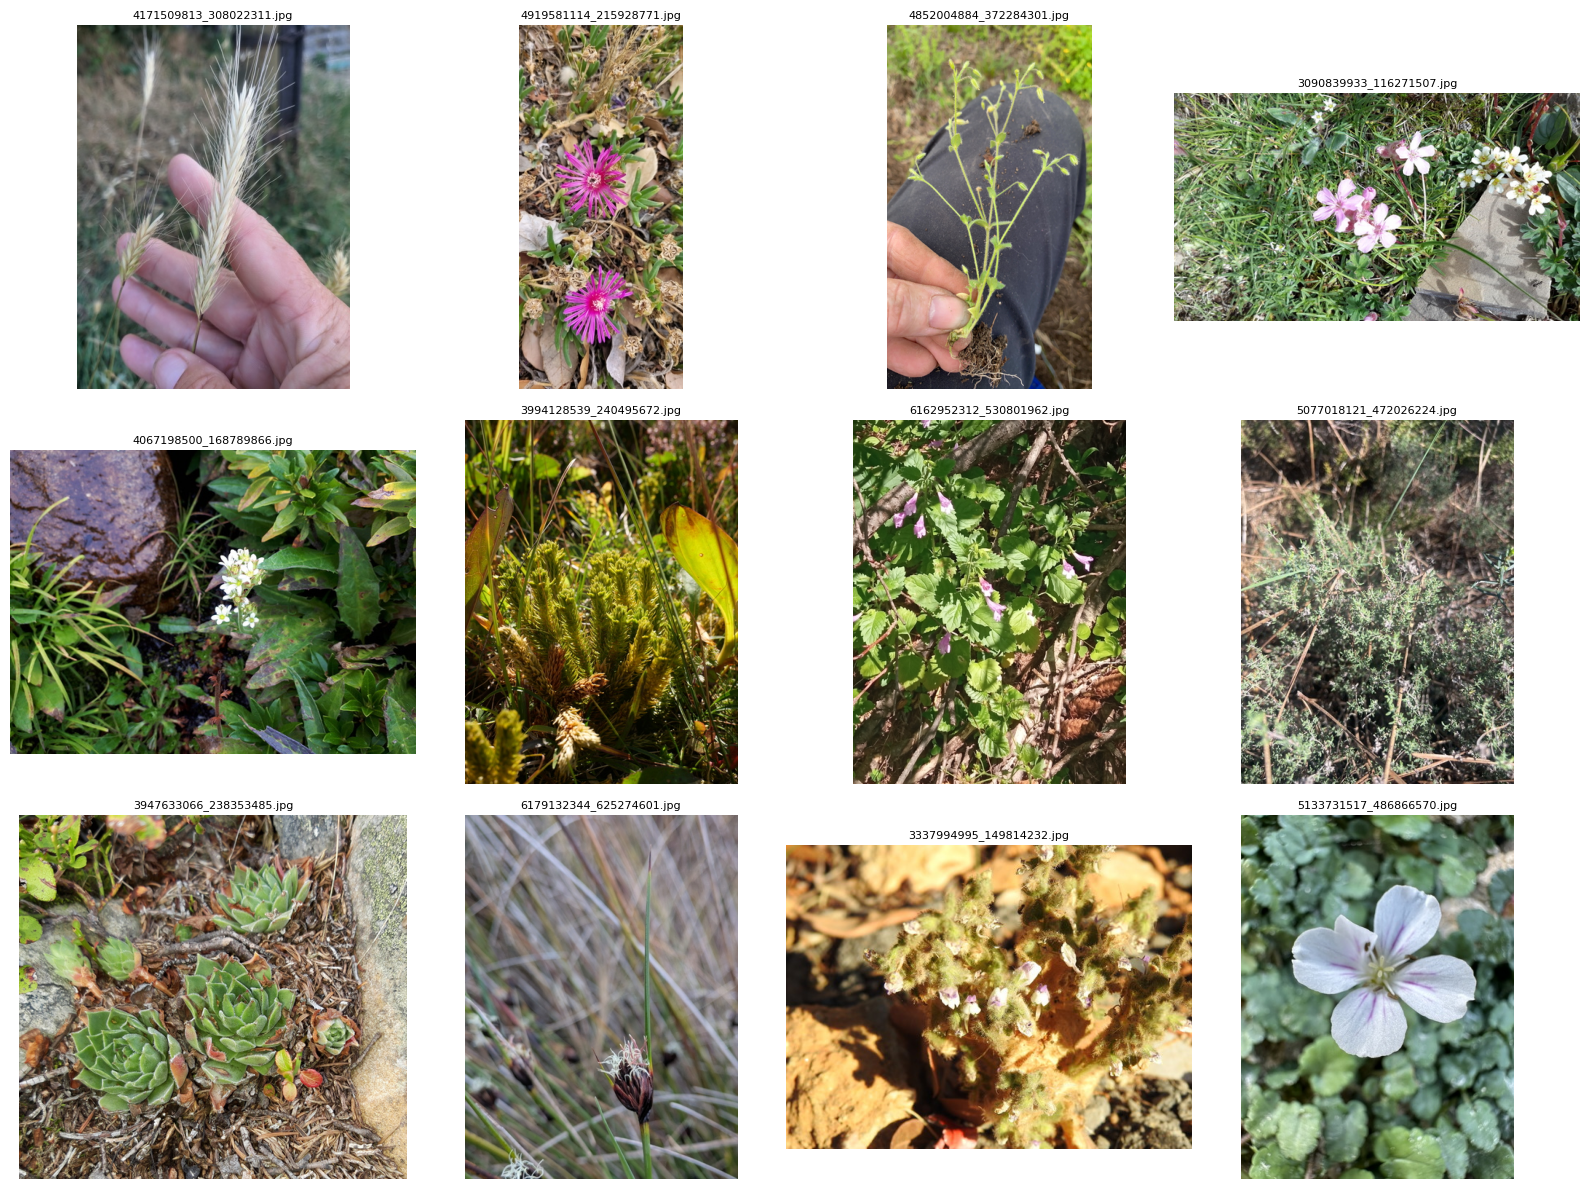

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Get duplicated image paths
dup_paths = (
    new_data[new_data.duplicated("image_path", keep=False)]
    ["image_path"]
    .drop_duplicates()
    .tolist()
)

print("Unique duplicated image paths:", len(dup_paths))

# Sample some duplicated paths
sample_paths = random.sample(dup_paths, min(12, len(dup_paths)))

plt.figure(figsize=(16, 12))

for i, path in enumerate(sample_paths):
    plt.subplot(3, 4, i + 1)

    try:
        img = Image.open(path).convert("RGB")
        plt.imshow(img)
        plt.title(os.path.basename(path), fontsize=8)
    except Exception as e:
        plt.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center")

    plt.axis("off")

plt.tight_layout()
plt.show()

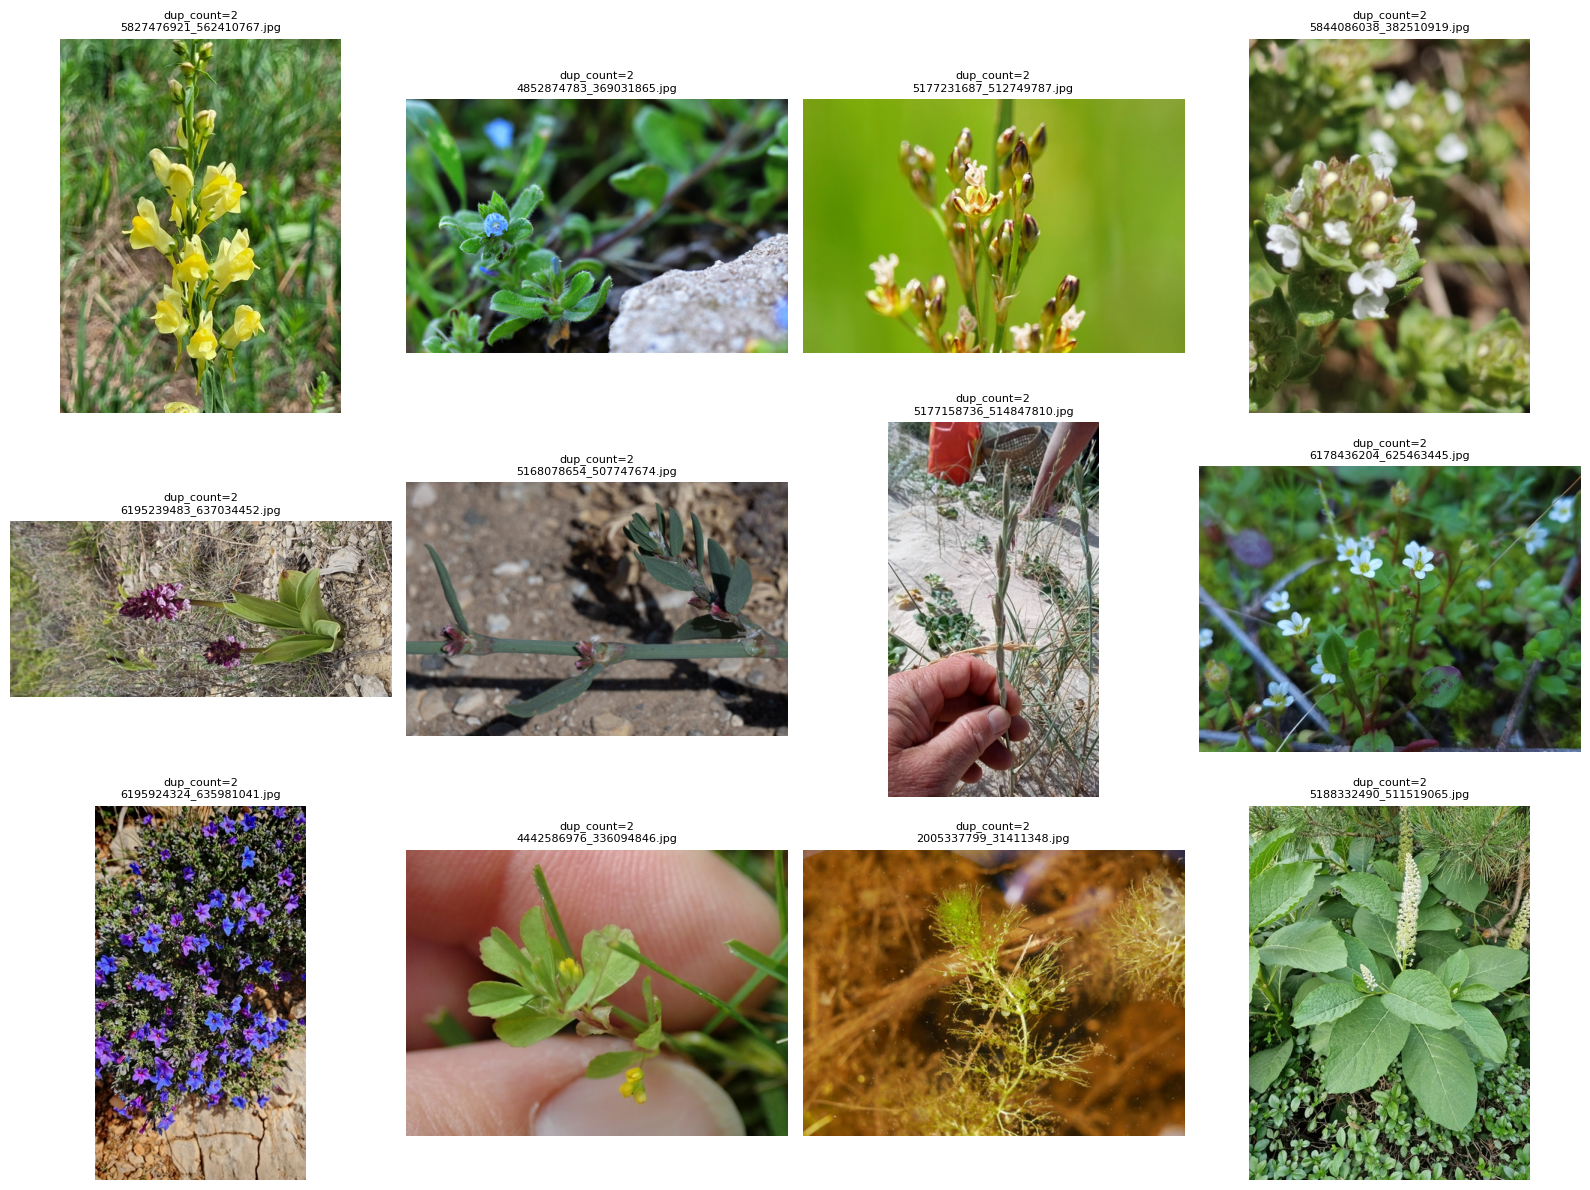

In [22]:
dup_counts = (
    new_data["image_path"]
    .value_counts()
    .reset_index()
)

dup_counts.columns = ["image_path", "count"]
dup_counts = dup_counts[dup_counts["count"] > 1]

sample_dup = dup_counts.sample(min(12, len(dup_counts)), random_state=42)

plt.figure(figsize=(16, 12))

for i, (_, row) in enumerate(sample_dup.iterrows()):
    path = row["image_path"]
    count = row["count"]

    plt.subplot(3, 4, i + 1)

    try:
        img = Image.open(path).convert("RGB")
        plt.imshow(img)
        plt.title(
            f"dup_count={count}\n{os.path.basename(path)}",
            fontsize=8,
        )
    except Exception as e:
        plt.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
dup_counts["count"].unique()

array([3, 2])

In [27]:
new_data_clean = new_data.drop_duplicates(subset=["image_path"]).copy()

print("Before:", len(new_data))
print("After:", len(new_data_clean))
print("Removed:", len(new_data) - len(new_data_clean))

Before: 1338626
After: 1245748
Removed: 92878


In [28]:
# Pick one duplicate image from the ones you visualized
example_path = sample_paths[0]

print("Example duplicate image path:")
print(example_path)

# Show every row with this same image_path
dup_example_rows = new_data[
    new_data["image_path"] == example_path
].copy()

dup_example_rows

Example duplicate image path:
/workspace/plantclef/raw/inat_research_grade/1361304/4171509813_308022311.jpg


,image_path,species_id,gbif_species_id,gbif_occurrence_id,license,scientific_name,url
445306,/workspace/plantclef/raw/inat_research_grade/1...,1361304,2706067,4171509813,http://creativecommons.org/licenses/by-nc/4.0/...,Hordeum bulbosum L.,https://inaturalist-open-data.s3.amazonaws.com...
575229,/workspace/plantclef/raw/inat_research_grade/1...,1361304,2706067,4171509813,http://creativecommons.org/licenses/by-nc/4.0/...,Hordeum bulbosum L.,https://inaturalist-open-data.s3.amazonaws.com...


In [21]:
old_license_counts = old["license_old"].value_counts(dropna=False).rename("old_count")
new_license_counts = new["license_new"].value_counts(dropna=False).rename("new_count")

license_compare = pd.concat([old_license_counts, new_license_counts], axis=1).fillna(0).astype(int)

license_compare

,old_count,new_count
cc-by-sa,1099727,0
http://creativecommons.org/licenses/by-nc/4.0/,210973,0
http://creativecommons.org/licenses/by-nc-nd/4.0/,44558,0
http://creativecommons.org/licenses/by/4.0/,35738,0
http://creativecommons.org/publicdomain/zero/1.0/,5597,0
http://creativecommons.org/licenses/by-nc-sa/4.0/,4544,0
http://creativecommons.org/licenses/by-sa/4.0/,2942,0
cc-by-nc,2511,0
http://creativecommons.org/licenses/by-nd/4.0/,1096,0
cc-by-nc-sa,245,0


In [30]:
out_path = "/workspace/plantclef/processed/inat_research_grade_manifest_clean.csv"

new_data_clean.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Rows:", len(new_data_clean))

Saved: /workspace/plantclef/processed/inat_research_grade_manifest_clean.csv
Rows: 1245748


In [31]:
import pandas as pd
from pathlib import Path

out_dir = Path("/workspace/plantclef/processed/old_new_image_overlap")

old_with_hashes_path = out_dir / "old_with_hashes.csv"
new_with_hashes_path = out_dir / "new_with_hashes.csv"
new_also_old_path = out_dir / "new_images_also_in_old_by_hash.csv"
new_not_old_path = out_dir / "new_images_not_in_old_by_hash.csv"
matches_path = out_dir / "matched_new_old_pairs_by_hash.csv"
species_summary_path = out_dir / "new_species_overlap_summary_by_hash.csv"

old = pd.read_csv(old_with_hashes_path, low_memory=False)
new = pd.read_csv(new_with_hashes_path, low_memory=False)
new_also_old = pd.read_csv(new_also_old_path, low_memory=False)
new_not_old = pd.read_csv(new_not_old_path, low_memory=False)
matches = pd.read_csv(matches_path, low_memory=False)
species_summary = pd.read_csv(species_summary_path, low_memory=False)

def fix_ok(df):
    if "ok" in df.columns:
        df["ok"] = df["ok"].map(lambda x: str(x).lower() in ["true", "1", "yes"])
    return df

old = fix_ok(old)
new = fix_ok(new)
new_also_old = fix_ok(new_also_old)
new_not_old = fix_ok(new_not_old)

print("Loaded files")
print("old:", old.shape)
print("new:", new.shape)
print("new_also_old:", new_also_old.shape)
print("new_not_old:", new_not_old.shape)
print("matches:", matches.shape)
print("species_summary:", species_summary.shape)

Loaded files
old: (1408033, 24)
new: (1245748, 10)
new_also_old: (0, 11)
new_not_old: (1245748, 11)
matches: (0, 17)
species_summary: (5037, 6)


In [32]:
old_valid = old[old["ok"] & old["img_hash"].notna()].copy()
new_valid = new[new["ok"] & new["img_hash"].notna()].copy()

old_hashes = set(old_valid["img_hash"])
new_hashes = set(new_valid["img_hash"])

shared_hashes = old_hashes & new_hashes

summary = pd.DataFrame({
    "metric": [
        "old rows",
        "new rows",
        "old readable rows",
        "new readable rows",
        "old unique hashes",
        "new unique hashes",
        "shared hashes",
        "new rows also in old",
        "new rows not in old",
        "old rows also in new",
        "new exact duplicate files internally",
        "old exact duplicate files internally",
    ],
    "value": [
        len(old),
        len(new),
        len(old_valid),
        len(new_valid),
        old_valid["img_hash"].nunique(),
        new_valid["img_hash"].nunique(),
        len(shared_hashes),
        int(new["exists_in_old_by_hash"].sum()) if "exists_in_old_by_hash" in new.columns else len(new_also_old),
        len(new_not_old),
        int(old["exists_in_new_by_hash"].sum()) if "exists_in_new_by_hash" in old.columns else None,
        len(new_valid) - new_valid["img_hash"].nunique(),
        len(old_valid) - old_valid["img_hash"].nunique(),
    ]
})

summary

,metric,value
0,old rows,1408033.0
1,new rows,1245748.0
2,old readable rows,1408033.0
3,new readable rows,1245748.0
4,old unique hashes,1407308.0
5,new unique hashes,1243276.0
6,shared hashes,0.0
7,new rows also in old,0.0
8,new rows not in old,1245748.0
9,old rows also in new,NaN


In [33]:
pct_summary = pd.DataFrame({
    "metric": [
        "percent of new readable images also in old",
        "percent of new readable images not in old",
        "percent of old readable images also in new",
        "percent internal duplicate files in new",
        "percent internal duplicate files in old",
    ],
    "percent": [
        100 * len(new_also_old) / max(len(new_valid), 1),
        100 * len(new_not_old) / max(len(new_valid), 1),
        100 * int(old.get("exists_in_new_by_hash", pd.Series(False, index=old.index)).sum()) / max(len(old_valid), 1),
        100 * (len(new_valid) - new_valid["img_hash"].nunique()) / max(len(new_valid), 1),
        100 * (len(old_valid) - old_valid["img_hash"].nunique()) / max(len(old_valid), 1),
    ]
})

pct_summary

,metric,percent
0,percent of new readable images also in old,0.000000
1,percent of new readable images not in old,100.000000
2,percent of old readable images also in new,0.000000
3,percent internal duplicate files in new,0.198435
4,percent internal duplicate files in old,0.051490


In [34]:
new_internal_dups = (
    new_valid[new_valid.duplicated("img_hash", keep=False)]
    .sort_values("img_hash")
    .copy()
)

print("New rows involved in duplicate file groups:", len(new_internal_dups))
print("New duplicate hash groups:", new_internal_dups["img_hash"].nunique())

new_internal_dup_summary = (
    new_internal_dups
    .groupby("img_hash")
    .agg(
        n_rows=("image_path", "count"),
        n_species=("species_id", "nunique"),
        n_gbif_species=("gbif_species_id", "nunique"),
        n_names=("scientific_name", "nunique"),
        example_species=("scientific_name", "first"),
        example_path=("image_path", "first"),
    )
    .reset_index()
    .sort_values("n_rows", ascending=False)
)

new_internal_dup_summary.head(30)

New rows involved in duplicate file groups: 4913
New duplicate hash groups: 2441


,img_hash,n_rows,n_species,n_gbif_species,n_names,example_species,example_path
2258,ec609dfdcaf3988a23d674f84ce3143e27b970ce0f519d...,5,1,1,1,Cytinus ruber (Fourr.) Fritsch,/workspace/plantclef/raw/inat_research_grade/1...
983,65b0279ae221c043553b1b26f82936c3f5eccf29447552...,4,1,1,1,Tuberaria guttata (L.) Fourr.,/workspace/plantclef/raw/inat_research_grade/1...
1728,b3163695d2b244624a9b1da90f2a8e5532f23da041c604...,4,2,2,1,Bupleurum spinosum Gouan,/workspace/plantclef/raw/inat_research_grade/1...
2257,ec350f6fa54603d52da94f9ad67df2401902e474a84809...,3,1,1,1,Teucrium capitatum subsp. majoricum (Rouy) Nyman,/workspace/plantclef/raw/inat_research_grade/1...
1276,83e6da6032f8cb9379d6857c9a38527f0349abe740e8e0...,3,1,1,1,Eriophorum scheuchzeri Hoppe,/workspace/plantclef/raw/inat_research_grade/1...
69,075ce3755c518191b73ac9e9183e9fc93984855882e6cd...,3,3,3,3,Cistus salviifolius L.,/workspace/plantclef/raw/inat_research_grade/1...
1085,7000a16fc6b9e5042a6c5798901590b0ff595fe73db35a...,3,1,1,1,Saponaria ocymoides L.,/workspace/plantclef/raw/inat_research_grade/1...
1727,b2f0353baa979ecf68740eb1736fc6f244a3ae18925c55...,3,1,1,1,Arctotis stoechadifolia P.J.Bergius,/workspace/plantclef/raw/inat_research_grade/1...
150,0f21df04aff5f9701196986c50e0b9793e0aaa670d1906...,3,1,1,1,Ononis reclinata L.,/workspace/plantclef/raw/inat_research_grade/1...
2155,e0f6e508acebf35d24dc39e728e775ea446b6fe3c7d1ff...,3,1,1,1,Opuntia elatior Mill.,/workspace/plantclef/raw/inat_research_grade/1...


In [35]:
old_species_counts = (
    old_valid
    .groupby("species_id")
    .agg(
        old_n_images=("image_path", "count"),
        old_n_unique_hashes=("img_hash", "nunique"),
        old_scientific_name=("species", "first"),
        old_genus=("genus", "first"),
        old_family=("family", "first"),
        old_gbif_species_id=("gbif_species_id", "first"),
    )
    .reset_index()
)

new_species_counts = (
    new_valid
    .groupby("species_id")
    .agg(
        new_n_images=("image_path", "count"),
        new_n_unique_hashes=("img_hash", "nunique"),
        new_scientific_name=("scientific_name", "first"),
        new_gbif_species_id=("gbif_species_id", "first"),
    )
    .reset_index()
)

species_compare = old_species_counts.merge(
    new_species_counts,
    on="species_id",
    how="outer",
    indicator=True
)

species_compare["status"] = species_compare["_merge"].map({
    "both": "shared",
    "left_only": "old_only",
    "right_only": "new_only",
})

species_compare["extra_new_images_vs_old"] = (
    species_compare["new_n_images"].fillna(0)
    - species_compare["old_n_images"].fillna(0)
)

species_compare["extra_new_unique_hashes_vs_old"] = (
    species_compare["new_n_unique_hashes"].fillna(0)
    - species_compare["old_n_unique_hashes"].fillna(0)
)

species_compare = species_compare.drop(columns=["_merge"])

species_compare.head()

,species_id,old_n_images,old_n_unique_hashes,old_scientific_name,old_genus,old_family,old_gbif_species_id,new_n_images,new_n_unique_hashes,new_scientific_name,new_gbif_species_id,status,extra_new_images_vs_old,extra_new_unique_hashes_vs_old
0,1355868,323,323,Lactuca virosa L.,Lactuca,Asteraceae,3140346.0,500.0,500.0,Lactuca virosa L.,3140346.0,shared,177.0,177.0
1,1355869,412,412,Crepis capillaris (L.) Wallr.,Crepis,Asteraceae,5403304.0,500.0,500.0,Crepis capillaris (L.) Wallr.,5403304.0,shared,88.0,88.0
2,1355870,439,439,Crepis foetida L.,Crepis,Asteraceae,5403470.0,NaN,NaN,NaN,NaN,old_only,-439.0,-439.0
3,1355871,290,290,Hypochaeris glabra L.,Hypochaeris,Asteraceae,3093911.0,500.0,499.0,Hypochaeris glabra L.,3093911.0,shared,210.0,209.0
4,1355872,464,464,Hypochaeris radicata L.,Hypochaeris,Asteraceae,3093702.0,300.0,300.0,Hypochaeris radicata L.,3093702.0,shared,-164.0,-164.0


In [36]:
shared_species = species_compare[species_compare["status"] == "shared"].copy()

shared_species["gbif_mismatch"] = (
    shared_species["old_gbif_species_id"].astype("Int64")
    != shared_species["new_gbif_species_id"].astype("Int64")
)

shared_species["name_mismatch"] = (
    shared_species["old_scientific_name"].astype(str).str.strip().str.lower()
    != shared_species["new_scientific_name"].astype(str).str.strip().str.lower()
)

mismatch_species = shared_species[
    shared_species["gbif_mismatch"] | shared_species["name_mismatch"]
].copy()

print("Shared species:", len(shared_species))
print("Species with GBIF/name mismatch:", len(mismatch_species))

mismatch_species[
    [
        "species_id",
        "old_scientific_name",
        "new_scientific_name",
        "old_gbif_species_id",
        "new_gbif_species_id",
        "gbif_mismatch",
        "name_mismatch",
        "old_n_images",
        "new_n_images",
    ]
].head(50)

Shared species: 5037
Species with GBIF/name mismatch: 386


,species_id,old_scientific_name,new_scientific_name,old_gbif_species_id,new_gbif_species_id,gbif_mismatch,name_mismatch,old_n_images,new_n_images
25,1355928,Taraxacum besarabicum (Hornem.) Hand.-Mazz.,Taraxacum bessarabicum (Hornem.) Hand.-Mazz.,5394232.0,5394232.0,False,True,155,215.0
26,1355932,Pelargonium graveolens L'Hér.,Pelargonium graveolens (Thunb.) L'Hér.,2891608.0,2891608.0,False,True,364,93.0
52,1355993,Erodium chium (L.) Willd.,Erodium chium (Burm.fil.) Willd.,3828217.0,3828217.0,False,True,183,101.0
84,1356072,Plantago ovata Forssk.,Plantago ovata var. fastigiata (E.Morris) S.C....,3189723.0,3189723.0,False,True,156,300.0
155,1356294,Cyperus longus L.,Cyperus longus var. tenuiflorus (Rottb.) Boeck...,8243603.0,8243603.0,False,True,313,300.0
158,1356297,Cladium mariscus (L.) Pohl,Cladium mariscus subsp. jamaicense (Crantz) Kük.,2731327.0,2731327.0,False,True,243,300.0
171,1356320,Capparis spinosa L.,Capparis mariana Jacq.,6370689.0,6370689.0,False,True,498,300.0
220,1356404,Pteridium aquilinum (L.) Kuhn,Pteridium pinetorum C.N.Page & R.R.Mill,5275012.0,5275012.0,False,True,283,500.0
277,1356581,Hedera iberica (McAll.) Ackerf. & J.Wen,Hedera iberica (Mc All.) Ackerf. & J.Wen,3036182.0,3036182.0,False,True,6,8.0
370,1356834,Cerastium ramosissimum Boiss.,Cerastium schmalhausenii Pacz.,7267109.0,7267109.0,False,True,97,52.0


In [37]:
import pandas as pd
from pathlib import Path

out_dir = Path("/workspace/plantclef/processed/old_new_image_overlap")

new = pd.read_csv(out_dir / "new_with_hashes.csv", low_memory=False)
old = pd.read_csv(out_dir / "old_with_hashes.csv", low_memory=False)

# Fix bool column if needed
for df in [new, old]:
    if "ok" in df.columns:
        df["ok"] = df["ok"].map(lambda x: str(x).lower() in ["true", "1", "yes"])

In [38]:
new_low_species = (
    new[new["ok"] & new["img_hash"].notna()]
    .groupby("species_id")
    .agg(
        n_images=("image_path", "count"),
        n_unique_images=("img_hash", "nunique"),
        scientific_name=("scientific_name", "first"),
        gbif_species_id=("gbif_species_id", "first"),
    )
    .reset_index()
    .sort_values(["n_unique_images", "n_images"], ascending=True)
)

new_low_species.head(50)

,species_id,n_images,n_unique_images,scientific_name,gbif_species_id
333,1357069,1,1,Spergularia heldreichii Foucaud,7781435
440,1357590,1,1,Filago micropodioides Lange,3115840
543,1358186,1,1,Biscutella frutescens Coss.,3041836
589,1358424,1,1,Sinapis flexuosa Poir.,3047638
622,1358523,1,1,Euphorbia akenocarpa Guss.,3067586
820,1359358,1,1,Melilotus infestus Guss.,2971033
1120,1360355,1,1,Rubus incanescens (DC.) Bertol.,2991367
1496,1361768,1,1,Leucanthemum lacustre (Brot.) Samp.,5401010
1724,1363222,1,1,Pimpinella anisum L.,8080300
2052,1379513,1,1,Hypericum annulatum subsp. annulatum,7329869


In [39]:
new_one_image_species = new_low_species[new_low_species["n_unique_images"] == 1]

print("Species with only 1 unique image in new:", len(new_one_image_species))

new_one_image_species.head(100)

Species with only 1 unique image in new: 81


,species_id,n_images,n_unique_images,scientific_name,gbif_species_id
333,1357069,1,1,Spergularia heldreichii Foucaud,7781435
440,1357590,1,1,Filago micropodioides Lange,3115840
543,1358186,1,1,Biscutella frutescens Coss.,3041836
589,1358424,1,1,Sinapis flexuosa Poir.,3047638
622,1358523,1,1,Euphorbia akenocarpa Guss.,3067586
...,...,...,...,...,...
4999,1744374,1,1,Limonium ugijarense Erben,4088612
5014,1744530,1,1,Hormathophylla cadevalliana (Pau) T.R.Dudley,3050686
5023,1744625,1,1,Facchinia valentina (Pau) Dillenb. & Kadereit,9070455
5024,1744635,1,1,Ranunculus cherubicus subsp. girelai Fern.Prie...,8593508


In [40]:
old_counts = (
    old[old["ok"] & old["img_hash"].notna()]
    .groupby("species_id")
    .agg(
        old_n_images=("image_path", "count"),
        old_n_unique_images=("img_hash", "nunique"),
        old_scientific_name=("species", "first"),
    )
    .reset_index()
)

new_counts = (
    new[new["ok"] & new["img_hash"].notna()]
    .groupby("species_id")
    .agg(
        new_n_images=("image_path", "count"),
        new_n_unique_images=("img_hash", "nunique"),
        new_scientific_name=("scientific_name", "first"),
    )
    .reset_index()
)

combined_low_species = old_counts.merge(
    new_counts,
    on="species_id",
    how="outer"
)

combined_low_species["old_n_images"] = combined_low_species["old_n_images"].fillna(0).astype(int)
combined_low_species["new_n_images"] = combined_low_species["new_n_images"].fillna(0).astype(int)
combined_low_species["old_n_unique_images"] = combined_low_species["old_n_unique_images"].fillna(0).astype(int)
combined_low_species["new_n_unique_images"] = combined_low_species["new_n_unique_images"].fillna(0).astype(int)

combined_low_species["total_n_images"] = (
    combined_low_species["old_n_images"] + combined_low_species["new_n_images"]
)

combined_low_species["total_n_unique_images"] = (
    combined_low_species["old_n_unique_images"] + combined_low_species["new_n_unique_images"]
)

combined_low_species["scientific_name"] = combined_low_species["old_scientific_name"].fillna(
    combined_low_species["new_scientific_name"]
)

combined_low_species = combined_low_species.sort_values(
    ["total_n_unique_images", "total_n_images"],
    ascending=True
)

combined_low_species[
    [
        "species_id",
        "scientific_name",
        "old_n_images",
        "new_n_images",
        "total_n_images",
        "old_n_unique_images",
        "new_n_unique_images",
        "total_n_unique_images",
    ]
].head(100)

,species_id,scientific_name,old_n_images,new_n_images,total_n_images,old_n_unique_images,new_n_unique_images,total_n_unique_images
390,1356885,Minuartia campestris L.,1,0,1,1,0,1
480,1357151,Helianthemum papillare Boiss.,1,0,1,1,0,1
661,1357858,Senecio eriopus Willk.,1,0,1,1,0,1
665,1357866,Senecio petraeus Boiss. & Reut.,1,0,1,1,0,1
720,1358118,Sedum lagascae Pau,1,0,1,1,0,1
...,...,...,...,...,...,...,...,...
6589,1651267,Festuca michaelis Cebolla & Rivas Ponce,1,0,1,1,0,1
6590,1651322,Festuca picoeuropeana Nava,1,0,1,1,0,1
6600,1652226,Koeleria caudata (Link) Steud.,1,0,1,1,0,1
6611,1654025,Poa × austrohercynica Wein,1,0,1,1,0,1


In [43]:
N = 100

low_data_species = combined_low_species[
    combined_low_species["total_n_unique_images"] < N
].copy()

print(f"Species with fewer than {N} total unique images:", len(low_data_species))

low_data_species[
    [
        "species_id",
        "scientific_name",
        "old_n_unique_images",
        "new_n_unique_images",
        "total_n_unique_images",
    ]
]

Species with fewer than 100 total unique images: 2697


,species_id,scientific_name,old_n_unique_images,new_n_unique_images,total_n_unique_images
390,1356885,Minuartia campestris L.,1,0,1
480,1357151,Helianthemum papillare Boiss.,1,0,1
661,1357858,Senecio eriopus Willk.,1,0,1
665,1357866,Senecio petraeus Boiss. & Reut.,1,0,1
720,1358118,Sedum lagascae Pau,1,0,1
...,...,...,...,...,...
6507,1646237,Linaria diffusa Hoffmanns. & Link,20,79,99
6531,1647138,Armeria caespitosa (Ortega) Boiss.,37,62,99
7469,1743681,Hormathophylla saxigena (Jord. & Fourr.) D.A.G...,94,5,99
7574,1743990,Adenocarpus argyrophyllus (Rivas Goday) Rivas ...,35,64,99


In [44]:
import pandas as pd

In [46]:
file = pd.read_csv("/root/workspace/PlantCLEF2026/src_experiments/i001_data_download/data/from_scratch/combined_old_new_manifest_full.csv")

/tmp/ipykernel_3621/3787081101.py:1: DtypeWarning: Columns (0: genus, 1: family) have mixed types. Specify dtype option on import or set low_memory=False.
  file = pd.read_csv("/root/workspace/PlantCLEF2026/src_experiments/i001_data_download/data/from_scratch/combined_old_new_manifest_full.csv")


In [47]:
import pandas as pd

def verify_species_gbif_mapping(df):
    df = df.copy()

    # Normalize gbif_species_id so 5284517.0 becomes 5284517
    df["gbif_species_id_clean"] = (
        df["gbif_species_id"]
        .astype("Int64")   # pandas nullable integer, keeps NaN as <NA>
    )

    # 1. species_id -> gbif_species_id
    species_to_gbif = (
        df.dropna(subset=["species_id", "gbif_species_id_clean"])
        .groupby("species_id")["gbif_species_id_clean"]
        .nunique()
        .sort_values(ascending=False)
    )

    bad_species_to_gbif = species_to_gbif[species_to_gbif > 1]

    # 2. gbif_species_id -> species_id
    gbif_to_species = (
        df.dropna(subset=["species_id", "gbif_species_id_clean"])
        .groupby("gbif_species_id_clean")["species_id"]
        .nunique()
        .sort_values(ascending=False)
    )

    bad_gbif_to_species = gbif_to_species[gbif_to_species > 1]

    print("Rows:", len(df))
    print("Unique species_id:", df["species_id"].nunique())
    print("Unique gbif_species_id:", df["gbif_species_id_clean"].nunique())
    print()
    print("species_id mapping to multiple gbif_species_id:", len(bad_species_to_gbif))
    print("gbif_species_id mapping to multiple species_id:", len(bad_gbif_to_species))

    return bad_species_to_gbif, bad_gbif_to_species

In [48]:
bad_species_to_gbif, bad_gbif_to_species = verify_species_gbif_mapping(file)

Rows: 2653781
Unique species_id: 7806
Unique gbif_species_id: 7796

species_id mapping to multiple gbif_species_id: 0
gbif_species_id mapping to multiple species_id: 0


In [49]:
bad_species_to_gbif.head(20)

Series([], Name: gbif_species_id_clean, dtype: int64)

In [50]:
bad_gbif_to_species.head(20)

Series([], Name: species_id, dtype: int64)

In [51]:
file

,image_path,image_name,species_id,gbif_species_id,scientific_name,license,source,genus,family,url,gbif_occurrence_id
0,/workspace/plantclef/raw/train/images_max_side...,59feabe1c98f06e7f819f73c8246bd8f1a89556b.jpg,1396710,5284517.0,Taxus baccata L.,cc-by-sa,old_plantclef,Taxus,Taxaceae,https://bs.plantnet.org/image/o/59feabe1c98f06...,NaN
1,/workspace/plantclef/raw/train/images_max_side...,dc273995a89827437d447f29a52ccac86f65476e.jpg,1396710,5284517.0,Taxus baccata L.,cc-by-sa,old_plantclef,Taxus,Taxaceae,https://bs.plantnet.org/image/o/dc273995a89827...,NaN
2,/workspace/plantclef/raw/train/images_max_side...,416235e7023a4bd1513edf036b6097efc693a304.jpg,1396710,5284517.0,Taxus baccata L.,cc-by-sa,old_plantclef,Taxus,Taxaceae,https://bs.plantnet.org/image/o/416235e7023a4b...,NaN
3,/workspace/plantclef/raw/train/images_max_side...,cbd18fade82c46a5c725f1f3d982174895158afc.jpg,1396710,5284517.0,Taxus baccata L.,cc-by-sa,old_plantclef,Taxus,Taxaceae,https://bs.plantnet.org/image/o/cbd18fade82c46...,NaN
4,/workspace/plantclef/raw/train/images_max_side...,f82c8c6d570287ebed8407cefcfcb2a51eaaf56e.jpg,1396710,5284517.0,Taxus baccata L.,cc-by-sa,old_plantclef,Taxus,Taxaceae,https://bs.plantnet.org/image/o/f82c8c6d570287...,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2653776,/workspace/plantclef/raw/inat_research_grade/1...,5920418442_457667790.jpg,1742070,5643852.0,Woodsia pinnatifida (Fomin) Shmakov,http://creativecommons.org/licenses/by-nc/4.0/...,new_inat,NaN,NaN,https://inaturalist-open-data.s3.amazonaws.com...,5.920418e+09
2653777,/workspace/plantclef/raw/inat_research_grade/1...,5920394252_462682964.jpg,1742070,5643852.0,Woodsia heterophylla (Turcz. ex Fomin) Shmakov,http://creativecommons.org/licenses/by-nc/4.0/...,new_inat,NaN,NaN,https://inaturalist-open-data.s3.amazonaws.com...,5.920394e+09
2653778,/workspace/plantclef/raw/inat_research_grade/1...,5920336227_224926576.jpg,1742070,5643852.0,Woodsia heterophylla (Turcz. ex Fomin) Shmakov,http://creativecommons.org/licenses/by-nc/4.0/...,new_inat,NaN,NaN,https://inaturalist-open-data.s3.amazonaws.com...,5.920336e+09
2653779,/workspace/plantclef/raw/inat_research_grade/1...,4987415300_451945806.jpg,1742070,5643852.0,Woodsia heterophylla (Turcz. ex Fomin) Shmakov,http://creativecommons.org/licenses/by-nc/4.0/...,new_inat,NaN,NaN,https://inaturalist-open-data.s3.amazonaws.com...,4.987415e+09


In [59]:
import pandas as pd

def fill_missing_genus_family(df, output_csv_path):
    df = df.copy()

    # Normalize missing values
    for col in ["genus", "family"]:
        df[col] = df[col].replace(["", "nan", "None", "NaN"], pd.NA)

    # Clean gbif id so 5284517.0 becomes 5284517
    if "gbif_species_id" in df.columns:
        df["gbif_species_id_clean"] = df["gbif_species_id"].astype("Int64")

    def fill_from_mapping(df, key_col, value_col):
        """
        Fill missing value_col using rows where key_col already has a known value_col.
        Only uses keys that map to exactly ONE unique value to avoid bad fills.
        """
        valid = df.dropna(subset=[key_col, value_col])

        mapping_counts = (
            valid.groupby(key_col)[value_col]
            .nunique()
        )

        safe_keys = mapping_counts[mapping_counts == 1].index

        mapping = (
            valid[valid[key_col].isin(safe_keys)]
            .drop_duplicates(subset=[key_col])
            .set_index(key_col)[value_col]
        )

        missing_before = df[value_col].isna().sum()

        df[value_col] = df[value_col].fillna(
            df[key_col].map(mapping)
        )

        missing_after = df[value_col].isna().sum()

        print(
            f"Filled {value_col} from {key_col}: "
            f"{missing_before - missing_after} rows"
        )

        return df

    # Fill genus and family using strongest identifiers first
    for value_col in ["genus", "family"]:
        df = fill_from_mapping(df, "species_id", value_col)

        if "gbif_species_id_clean" in df.columns:
            df = fill_from_mapping(df, "gbif_species_id_clean", value_col)

        # df = fill_from_mapping(df, "scientific_name", value_col)

    # Optional: infer genus from scientific_name if still missing
    missing_genus_before = df["genus"].isna().sum()

    # df["genus"] = df["genus"].fillna(
    #     df["scientific_name"].str.split().str[0]
    # )

    missing_genus_after = df["genus"].isna().sum()

    print(
        f"Inferred genus from scientific_name: "
        f"{missing_genus_before - missing_genus_after} rows"
    )

    # Remove helper column before saving
    if "gbif_species_id_clean" in df.columns:
        df = df.drop(columns=["gbif_species_id_clean"])

    print()
    print("Remaining missing genus:", df["genus"].isna().sum())
    print("Remaining missing family:", df["family"].isna().sum())

    df.to_csv(output_csv_path, index=False)
    print(f"Saved to: {output_csv_path}")

    return df

In [60]:
output_path = "/root/workspace/PlantCLEF2026/src_experiments/i001_data_download/data/training_usage/metadata_filled_genus_family.csv"

df_filled = fill_missing_genus_family(file, output_path)

Filled genus from species_id: 1245748 rows
Filled genus from gbif_species_id_clean: 0 rows
Filled family from species_id: 1245748 rows


Filled family from gbif_species_id_clean: 0 rows
Inferred genus from scientific_name: 0 rows

Remaining missing genus: 0
Remaining missing family: 0
Saved to: /root/workspace/PlantCLEF2026/src_experiments/i001_data_download/data/training_usage/metadata_filled_genus_family.csv


In [62]:
print("Before:")
print(file[["genus", "family"]].isna().sum())

print("After:")
print(df_filled[["genus", "family"]].isna().sum())

Before:
genus     1245748
family    1245748
dtype: int64
After:
genus     0
family    0
dtype: int64
